In [1]:
import pandas as pd

In [36]:
df = pd.read_csv('data/WAR Predictor 15-25.csv')

In [37]:
df.head()

,Season,Name,Team,PA,WAR,BB%,K%,Barrel%,HardHit%,EV,...,LD%,GB%,FB%,Pull%,Cent%,Oppo%,Spd,NameASCII,PlayerId,MLBAMID
0,2025,Oneil Cruz,PIT,544,1.580288,0.117647,0.319853,0.178808,0.566225,95.835664,...,0.145695,0.480132,0.374172,0.407285,0.384106,0.208609,7.068212,Oneil Cruz,21711,665833
1,2017,Giancarlo Stanton,MIA,692,6.434607,0.122832,0.235549,0.173913,0.457666,92.009653,...,0.160183,0.446224,0.393593,0.446224,0.352403,0.201373,2.259233,Giancarlo Stanton,4949,519317
2,2021,Giancarlo Stanton,NYY,579,3.050541,0.108808,0.271157,0.157303,0.556180,95.100852,...,0.185393,0.446629,0.367978,0.379213,0.339888,0.280899,0.603186,Giancarlo Stanton,4949,519317
3,2018,Giancarlo Stanton,NYY,705,3.772407,0.099291,0.299291,0.151442,0.507212,93.694444,...,0.185096,0.449519,0.365385,0.389423,0.370192,0.240385,3.768260,Giancarlo Stanton,4949,519317
4,2024,Oneil Cruz,PIT,599,3.603457,0.085142,0.302170,0.156593,0.549451,95.480663,...,0.184066,0.478022,0.337912,0.420330,0.329670,0.250000,6.152637,Oneil Cruz,21711,665833


In [38]:
# removing the shortened 2020 season
df = df[df['Season'] != 2020]

In [39]:
df.columns

Index(['Season', 'Name', 'Team', 'PA', 'WAR', 'BB%', 'K%', 'Barrel%',
       'HardHit%', 'EV', 'LA', 'maxEV', 'BABIP', 'LD%', 'GB%', 'FB%', 'Pull%',
       'Cent%', 'Oppo%', 'Spd', 'NameASCII', 'PlayerId', 'MLBAMID'],
      dtype='object')

In [40]:
y = df['WAR']
x = df.drop(['Season', 'PA', 'WAR', 'Name', 'Team', 'NameASCII', 'PlayerId', 'MLBAMID'], axis=1)

In [41]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')


Mean Squared Error: 1.4119876789180352
R^2 Score: 0.66130017599024


In [44]:
coeffs = pd.Series(model.coef_, index=x.columns).sort_values()
print(coeffs)

LD%        -1.171507e+07
GB%        -1.171506e+07
FB%        -1.171506e+07
K%         -2.025082e+01
LA         -2.822622e-02
maxEV      -2.807268e-02
EV          3.905103e-02
Spd         3.905401e-01
HardHit%    1.041132e+00
BB%         1.460599e+01
Barrel%     2.066325e+01
BABIP       3.453304e+01
Cent%       5.347251e+06
Oppo%       5.347254e+06
Pull%       5.347258e+06
dtype: float64


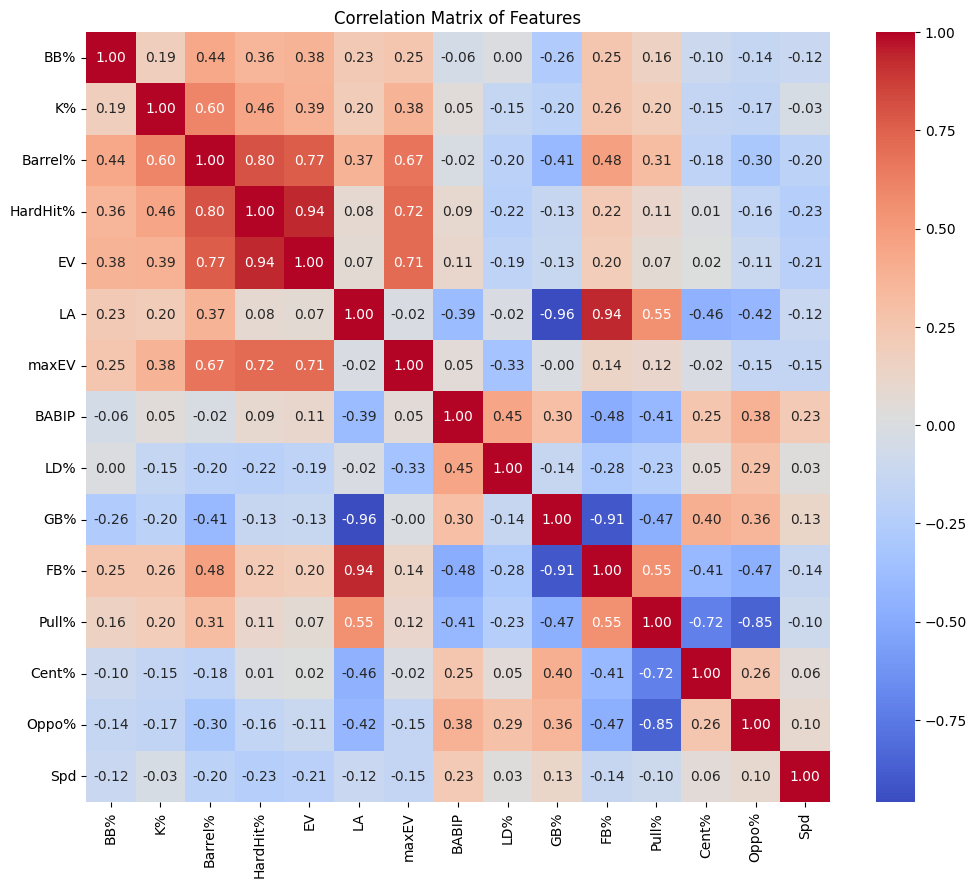

In [45]:
# correlation matrix 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

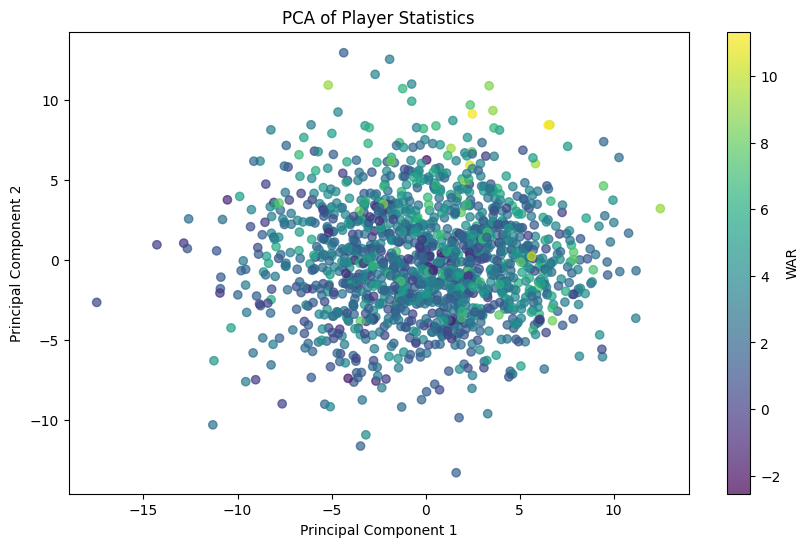

In [46]:
# principal component analysis
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label='WAR')
plt.title('PCA of Player Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [47]:
# most important features from PCA
pca_components = pd.DataFrame(pca.components_, columns=x.columns)
print(pca_components)

# feature importance from linear regression
feature_importance = pd.Series(model.coef_, index=x.columns).sort_values(ascending=False)
print(feature_importance)

        BB%        K%   Barrel%  HardHit%        EV        LA     maxEV  \
0  0.001788  0.002740  0.003912  0.002156  0.056112  0.996456  0.010244   
1  0.002641  0.006015  0.008660  0.018550  0.522976 -0.044182  0.844716   

      BABIP       LD%       GB%       FB%     Pull%     Cent%     Oppo%  \
0 -0.002873 -0.000157 -0.014278  0.014434  0.007291 -0.003260 -0.004031   
1  0.000769 -0.002363  0.000003  0.002360  0.001335  0.000137 -0.001472   

        Spd  
0 -0.057364  
1 -0.102575  
Pull%       5.347258e+06
Oppo%       5.347254e+06
Cent%       5.347251e+06
BABIP       3.453304e+01
Barrel%     2.066325e+01
BB%         1.460599e+01
HardHit%    1.041132e+00
Spd         3.905401e-01
EV          3.905103e-02
maxEV      -2.807268e-02
LA         -2.822622e-02
K%         -2.025082e+01
FB%        -1.171506e+07
GB%        -1.171506e+07
LD%        -1.171507e+07
dtype: float64


In [48]:
# trying a random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_y_pred = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, rf_y_pred)
print(f'Random Forest Mean Squared Error: {rf_mse}')
rf_r2 = r2_score(y_test, rf_y_pred)
print(f'Random Forest R^2 Score: {rf_r2}')

Random Forest Mean Squared Error: 1.8369815007647416
Random Forest R^2 Score: 0.55935499982906


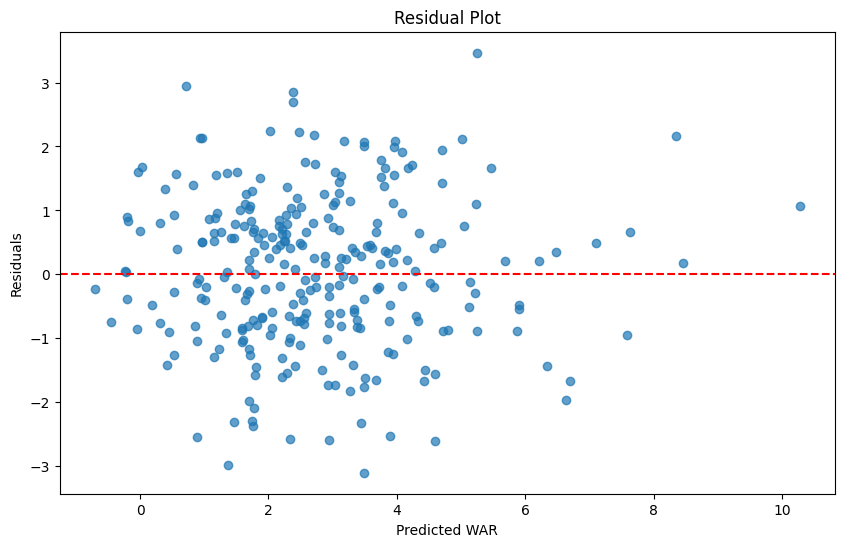

In [49]:
# residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted WAR')
plt.ylabel('Residuals')
plt.show()

In [50]:
# using the linear model to predict WAR for each player in the dataset
df['Predicted_WAR'] = model.predict(x)
df[['Name', 'Season', 'WAR', 'Predicted_WAR']].head(20)

,Name,Season,WAR,Predicted_WAR
0,Oneil Cruz,2025,1.580288,3.021306
1,Giancarlo Stanton,2017,6.434607,3.839380
2,Giancarlo Stanton,2021,3.050541,2.753102
3,Giancarlo Stanton,2018,3.772407,3.354708
4,Oneil Cruz,2024,3.603457,4.749037
5,Ronald Acuña Jr.,2023,9.154090,8.476240
6,Aaron Judge,2017,8.695028,8.566621
7,Vladimir Guerrero Jr.,2025,3.887598,4.644888
8,Shohei Ohtani,2025,7.480309,8.352347
9,Manny Machado,2021,4.476650,5.083128


In [51]:
# identifying players with the largest prediction errors
df['Prediction_Error'] = df['WAR'] - df['Predicted_WAR']
df['Absolute_Error'] = df['Prediction_Error'].abs()
top_errors = df.sort_values('Absolute_Error', ascending=False).head(10)
print(top_errors[['Name', 'Season', 'WAR', 'Predicted_WAR', 'Prediction_Error']])

                  Name  Season       WAR  Predicted_WAR  Prediction_Error
214        Cal Raleigh    2025  9.059341       5.093167          3.966173
382      Robinson Canó    2016  6.392560       2.652888          3.739672
224   Francisco Lindor    2018  7.797905       4.109943          3.687962
1457        Nick Ahmed    2018  4.039529       0.479185          3.560344
346     Josh Donaldson    2015  8.710970       5.245233          3.465737
1399      Alex Bregman    2019  8.326162       4.910204          3.415958
93       Carlos Correa    2021  6.287862       2.927693          3.360169
705     Russell Martin    2015  4.467947       1.245652          3.222295
1063  Charlie Blackmon    2021 -0.057567       3.077960         -3.135527
424        MJ Melendez    2023  0.383182       3.484847         -3.101665


In [53]:
# identifying players over their careers with the largest cumulative prediction errors
career_errors = df.groupby('Name')['Prediction_Error'].sum().abs().sort_values(ascending=False).head(10)
print(career_errors)

Name
Francisco Lindor     18.558859
Nolan Arenado        13.366350
Nick Castellanos     13.288537
Eugenio Suárez       12.073471
Charlie Blackmon     11.942298
Andrew Benintendi    11.386535
Alex Bregman          9.845455
Cal Raleigh           9.137015
Manny Machado         8.887758
Willy Adames          8.518232
Name: Prediction_Error, dtype: float64


In [54]:
# finding players with the largest positive and negative predicition errors over their careers
career_errors_signed = df.groupby('Name')['Prediction_Error'].sum().sort_values()
print("Top 10 Players with Largest Positive Cumulative Prediction Errors:")
print(career_errors_signed.tail(10))
print("\nTop 10 Players with Largest Negative Cumulative Prediction Errors:")
print(career_errors_signed.head(10))

Top 10 Players with Largest Positive Cumulative Prediction Errors:
Name
Brandon Crawford     7.165422
Matt Chapman         7.589704
Jonathan Schoop      8.299969
Willy Adames         8.518232
Manny Machado        8.887758
Cal Raleigh          9.137015
Alex Bregman         9.845455
Eugenio Suárez      12.073471
Nolan Arenado       13.366350
Francisco Lindor    18.558859
Name: Prediction_Error, dtype: float64

Top 10 Players with Largest Negative Cumulative Prediction Errors:
Name
Nick Castellanos    -13.288537
Charlie Blackmon    -11.942298
Andrew Benintendi   -11.386535
Andrew McCutchen     -7.972057
Carlos Santana       -7.707898
Josh Bell            -7.199617
Albert Pujols        -7.040635
J.D. Martinez        -6.287965
Shin-Soo Choo        -6.137431
Luis Arraez          -5.977522
Name: Prediction_Error, dtype: float64
